In [1]:
from DatasetLoading import RepairDatasetLoader
from RayRepresentationEncoding import RayRepresentationEncoder
import numpy as np
from torch.utils.data import DataLoader, TensorDataset
import torch.nn as nn
import lightning as L
import torch
from lightning.pytorch.loggers import WandbLogger
from scipy.spatial.transform import Rotation

In [2]:
import PairRotationPrediction

In [ ]:
model = PairRotationPrediction.get_model()
dataset = PairRotationPrediction.get_dataset(rays_folder_name="RayPairs1k30D")
#model = PairRotationPrediction.load_from_checkpoint("pieceRotationCheckpoints/epoch=29-step=23760.ckpt")
#model.learning_rate = 1e-4


Seed set to 42
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
wandb: WARNING The anonymous setting has no effect and will be removed in a future version.
wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from /home/enego/.netrc.
wandb: Currently logged in as: enegocomley (enegocomley-enego-couk) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


In [7]:
model, trainer = PairRotationPrediction.train(model, dataset)

In [10]:
angles = []
for (ray_colours_1, ray_locations_1, ray_colours_2, ray_locations_2, gt_rotation) in test_ray_dataloader.dataset:
    angles.append(Rotation.from_quat(gt_rotation).as_quat())
test_angles = np.array(angles)
angles = []
for (ray_colours_1, ray_locations_1, ray_colours_2, ray_locations_2, gt_rotation) in train_ray_dataloader.dataset:
    angles.append(Rotation.from_quat(gt_rotation).as_quat())
train_angles = np.array(angles)


In [30]:
def get_angle(angle_array):
    angles = angle_array
    w = angles[:, -1]
    theta = np.arccos(w) * 2
    return np.rad2deg(theta)

In [16]:
test_theta = get_angle(test_angles)
train_theta = get_angle(train_angles)

In [8]:
import matplotlib.pyplot as plt
import seaborn as sns
sns.set(style="whitegrid")


NameError: name 'test_theta' is not defined

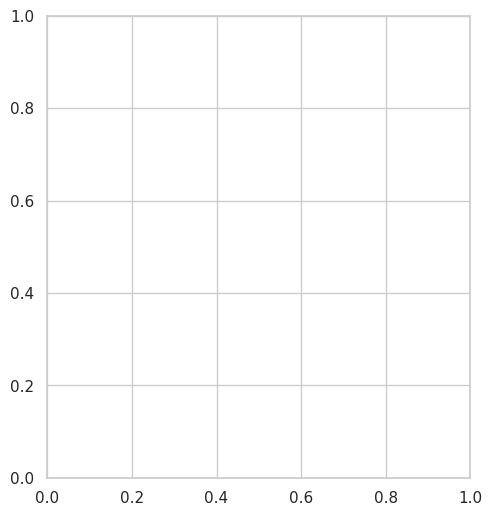

In [27]:
plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)

# Plot both test and train theta on a single histogram
sns.histplot(test_theta, bins=30, color='blue', label='Test Theta', kde=True, stat="density", alpha=0.6)
sns.histplot(train_theta, bins=30, color='orange', label='Train Theta', kde=True, stat="density", alpha=0.6)
plt.title('Distribution of Angle Test and Train Sets')
plt.xlabel('Theta (degrees)')
plt.ylabel('Density')def sample_ray(self, rays_o, rays_d, is_train=True, N_samples=-1):
        bounding_aabb = torch.tensor([[-10, -10, -10], [10, 10, 10]]).to(device)stepsize =

        N_samples = N_samples if N_samples>0 else self.nSamples
        stepsize = self.stepSize
        near, far = self.near_far
        vec = torch.where(rays_d==0, torch.full_like(rays_d, 1e-6), rays_d)
        rate_a = (bounding_aabb[1] - rays_o) / vec
        rate_b = (bounding_aabb[0] - rays_o) / vec
        t_min = torch.minimum(rate_a, rate_b).amax(-1).clamp(min=near, max=far)

        rng = torch.arange(N_samples)[None].float()
        if is_train:
            rng = rng.repeat(rays_d.shape[-2],1)
            rng += torch.rand_like(rng[:,[0]])
        step = stepsize * rng.to(rays_o.device)
        interpx = (t_min[...,None] + step)

        rays_pts = rays_o[...,None,:] + rays_d[...,None,:] * interpx[...,None]
        mask_outbbox = ((self.aabb[0]>rays_pts) | (rays_pts>self.aabb[1])).any(dim=-1)

        return rays_pts, interpx, ~mask_outbbox
plt.legend()
plt.show()


In [22]:
a = np.array([Rotation.random().as_quat() for x in range(10000)])
b = np.array([Rotation.random().as_quat() for x in range(10000)])

/tmp/ipykernel_2741923/3863113245.py:10: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


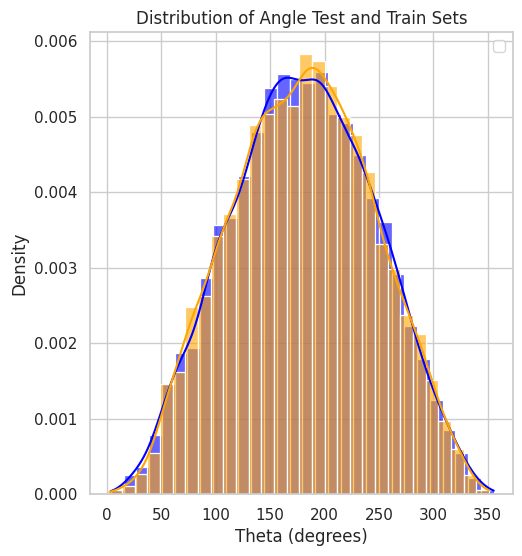

In [31]:
plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)

# Plot both test and train theta on a single histogram
sns.histplot(get_angle(a), bins=30, color='blue', kde=True, stat="density", alpha=0.6)
sns.histplot(get_angle(b), bins=30, color='orange', kde=True, stat="density", alpha=0.6)
plt.title('Distribution of Angle Test and Train Sets')
plt.xlabel('Theta (degrees)')
plt.ylabel('Density')
plt.legend()
plt.show()


/tmp/ipykernel_2741923/954050639.py:10: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


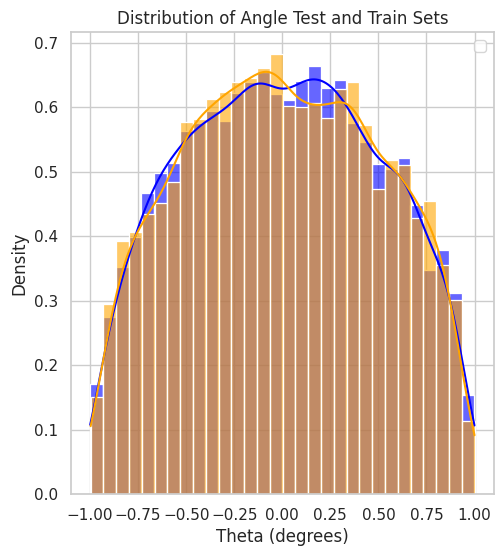

In [40]:
plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)

# Plot both test and train theta on a single histogram
sns.histplot(a[:, -1], bins=30, color='blue', kde=True, stat="density", alpha=0.6)
sns.histplot(b[:, -1], bins=30, color='orange', kde=True, stat="density", alpha=0.6)
plt.title('Distribution of Angle Test and Train Sets')
plt.xlabel('Theta (degrees)')
plt.ylabel('Density')
plt.legend()
plt.show()


In [29]:
a

array([[ 0.84295651,  0.37774015, -0.27564773,  0.26599818],
       [-0.18885884, -0.5981312 , -0.37666108, -0.68168749],
       [-0.39356205,  0.73035379,  0.31280645, -0.46243311],
       ...,
       [ 0.91223643, -0.01601498, -0.32036121, -0.2548272 ],
       [ 0.10885326, -0.71230153,  0.69162897, -0.04926326],
       [-0.04479972, -0.56430386,  0.18869249,  0.80246451]],
      shape=(10000, 4))

In [32]:
def plot_rays_colored(rays, rgb_map, point_size=6, title="Rays colored by rgb_map", special_lim=False):
    """
    rays: torch.Tensor or np.ndarray, shape (N, 3) or positional-encoded (N, D)
    rgb_map: torch.Tensor or np.ndarray, shape (N, 3), values in [0,1]
    """
    # convert to numpy
    if hasattr(rays, "detach"):
        rays_np = rays.detach().cpu().numpy()
    else:
        rays_np = np.array(rays)

    if hasattr(rgb_map, "detach"):
        colors = rgb_map.detach().cpu().numpy()
    else:
        colors = np.array(rgb_map)

    # normalize colors to [0,1]
    colors = np.clip(colors, 0.0, 1.0)

    pts = rays_np


    # plot
    x, y, z = pts.T
    fig = plt.figure(figsize=(8, 8))
    ax = fig.add_subplot(111, projection='3d')
    sc = ax.scatter(x, y, z, c=colors, s=point_size)
    # try equal aspect, fallback to manual limits
    if not special_lim:
        try:
            ax.set_box_aspect([1, 1, 1])
        except Exception:
            max_range = np.array([x.max()-x.min(), y.max()-y.min(), z.max()-z.min()]).max() / 2.0
            mid_x = (x.max()+x.min()) * 0.5
            mid_y = (y.max()+y.min()) * 0.5
            mid_z = (z.max()+z.min()) * 0.5
            ax.set_xlim(-1, 1)
            ax.set_ylim(-1, 1)
            ax.set_zlim(-1, 1)
    else:
        ax.set_xlim(-0.8, 0.8)
        ax.set_ylim(-0.8, 0.8)
        ax.set_zlim(-0.8, 0.8)

    ax.set_xlabel('X')
    ax.set_ylabel('Y')
    ax.set_zlabel('Z')
    plt.title(title)
    plt.show()

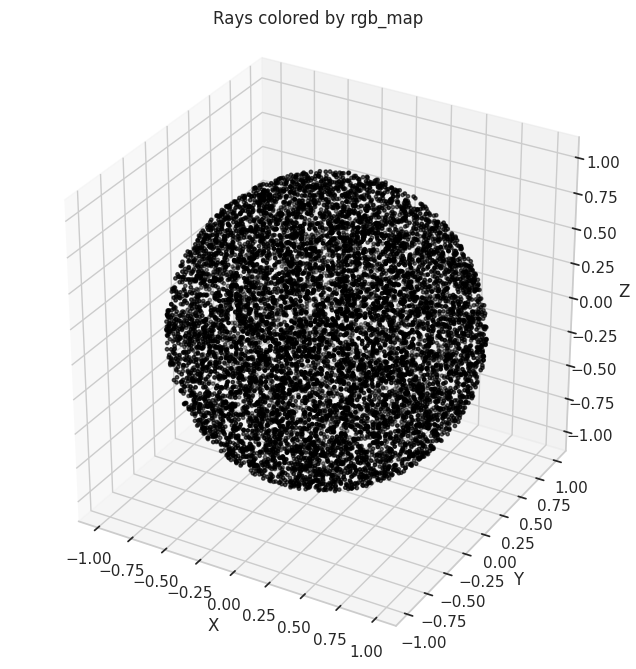

In [42]:
plot_rays_colored(a[:, 1:], np.zeros_like(a[:, :3]))

In [38]:
t = np.random.uniform(-1, 1, size=(10000, 4))

In [7]:
plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)

# Plot both test and train theta on a single histogram
sns.histplot(t[:, -1], bins=30, color='blue', kde=True, stat="density", alpha=0.6)
plt.title('Distribution of Angle Test and Train Sets')
plt.xlabel('Theta (degrees)')
plt.ylabel('Density')
plt.legend()
plt.show()


NameError: name 'plt' is not defined

In [36]:
np.max(a[:, :3])

np.float64(0.9984286750724072)

In [37]:
np.min(a[:, :3])


np.float64(-0.9992644121969994)

In [45]:
piece_names = test_ray_dataloader.dataset.ray_piece_names + train_ray_dataloader.dataset.ray_piece_names

In [46]:
len(piece_names)

47900

In [47]:
rotations = {}
for piece_name in piece_names:
    ray_colours, piece_rotation, ray_locations = test_ray_dataloader.dataset.get_rays_from_file(piece_name)
    rotations[piece_name] = Rotation.from_matrix(torch.linalg.inv(piece_rotation).numpy()).as_quat()

In [50]:
import struct


In [51]:
def save_quaternions(filename: str, quat_dict: dict):
    """
    Save a dictionary mapping string -> numpy array of length 4 to a compact binary file.

    Binary format (little-endian):
    [int32 num_items]
    for each item:
      [int32 key_len][key bytes UTF-8][float32 x][float32 y][float32 z][float32 w]

    Quaternion ordering saved: [x, y, z, w]
    """
    # Validate input type
    if not isinstance(quat_dict, dict):
        raise TypeError("quat_dict must be a dict[str, np.ndarray]")

    with open(filename, "wb") as f:
        # number of items (int32 little-endian)
        f.write(struct.pack("<i", len(quat_dict)))

        for key, val in quat_dict.items():
            if not isinstance(key, str):
                raise TypeError("All keys must be strings")

            key_bytes = key.encode("utf-8")
            # write key length and key bytes
            f.write(struct.pack("<i", len(key_bytes)))
            f.write(key_bytes)

            # convert value to numpy array of 4 float32 values
            arr = np.asarray(val, dtype=np.float32).ravel()
            if arr.size != 4:
                raise ValueError(f"Value for key '{key}' must contain exactly 4 elements (got {arr.size})")
            # ensure little-endian float32 bytes
            arr_le = arr.astype("<f4", copy=False)
            f.write(arr_le.tobytes())

In [52]:
save_quaternions("piece_rotations.bin", rotations)

In [9]:
import os

In [10]:
original_datadir = os.path.expanduser("~/Documents/masters/datasets/RePAIR/")

In [11]:


test_split_location = os.path.join(original_datadir, "test.txt")
with open(test_split_location, 'r') as f:
    puzzle_test_split = [f.strip() for f in f.readlines()]
train_split_location = os.path.join(original_datadir, "train.txt")
with open(train_split_location, 'r') as f:
    puzzle_train_split = [f.strip() for f in f.readlines()]



In [12]:
# Split the train split into train and val splits after shuffling
#import random
#random.seed(42)
#random.shuffle(puzzle_train_split)
#val_split_size = int(0.15 * len(puzzle_train_split))
#puzzle_val_split = puzzle_train_split[:val_split_size]
#puzzle_train_split = puzzle_train_split[val_split_size:]

In [13]:
# Save the new splits to files
#val_split_location = os.path.join(original_datadir, "val.txt")
#with open(val_split_location, 'w') as f:
#    for item in puzzle_val_split:
#        f.write(item + '\n')
#train_split_location = os.path.join(original_datadir, "train.txt")
#with open(train_split_location, 'w') as f:
#    for item in puzzle_train_split:
#        f.write(item + '\n')

In [14]:
len(puzzle_train_split)

83

In [8]:
len(puzzle_test_split)

24

In [4]:
self.original_datadir = os.path.join(self.original_datadir, "SOLVED")

NameError: name 'self' is not defined

In [18]:
objectsBB = torch.tensor([-1.236509, -0.559275, -1.461768, 1.236509, 0.559275, 1.461768])

In [17]:
def sample_ray(rays, is_train=False, N_samples=-1):
        rays_o = rays * torch.norm(objectsBB.absolute().amax(0)).cpu().item()
        rays_d = - rays
        bounding_aabb = torch.tensor([[-10, -10, -10], [10, 10, 10]]).to(rays.device)

        N_samples = N_samples if N_samples>0 else 250

        near = 0.01
        far = torch.norm(objectsBB.absolute().amax(0)).cpu().item()
        stepsize = far/N_samples
        vec = torch.where(rays_d==0, torch.full_like(rays_d, 1e-6), rays_d)
        rate_a = (bounding_aabb[1] - rays_o) / vec
        rate_b = (bounding_aabb[0] - rays_o) / vec
        t_min = torch.minimum(rate_a, rate_b).amax(-1).clamp(min=near, max=far)

        rng = torch.arange(N_samples)[None].float()
        if is_train:
            rng = rng.repeat(rays_d.shape[-2],1)
            rng += torch.rand_like(rng[:,[0]])
        step = stepsize * rng.to(rays_o.device)
        interpx = (t_min[...,None] + step)

        print(rays_o.shape, rays_d.shape, interpx.shape)

        rays_pts = rays_o[...,None,:] + rays_d[...,None,:] * interpx[...,None]

        return rays_pts

def plot_rays_colored(rays, rgb_map, point_size=6, title="Rays colored by rgb_map", special_lim=False):
    """
    rays: torch.Tensor or np.ndarray, shape (N, 3) or positional-encoded (N, D)
    rgb_map: torch.Tensor or np.ndarray, shape (N, 3), values in [0,1]
    """
    # convert to numpy
    if hasattr(rays, "detach"):
        rays_np = rays.detach().cpu().numpy()
    else:
        rays_np = np.array(rays)

    if hasattr(rgb_map, "detach"):
        colors = rgb_map.detach().cpu().numpy()
    else:
        colors = np.array(rgb_map)

    # normalize colors to [0,1]
    colors = np.clip(colors, 0.0, 1.0)

    pts = rays_np


    # plot
    x, y, z = pts.T
    fig = plt.figure(figsize=(8, 8))
    ax = fig.add_subplot(111, projection='3d')
    sc = ax.scatter(x, y, z, c=colors, s=point_size)
    # try equal aspect, fallback to manual limits
    if not special_lim:
        try:
            ax.set_box_aspect([1, 1, 1])
        except Exception:
            max_range = np.array([x.max()-x.min(), y.max()-y.min(), z.max()-z.min()]).max() / 2.0
            mid_x = (x.max()+x.min()) * 0.5
            mid_y = (y.max()+y.min()) * 0.5
            mid_z = (z.max()+z.min()) * 0.5
            ax.set_xlim(-1, 1)
            ax.set_ylim(-1, 1)
            ax.set_zlim(-1, 1)
    else:
        ax.set_xlim(-0.8, 0.8)
        ax.set_ylim(-0.8, 0.8)
        ax.set_zlim(-0.8, 0.8)

    ax.set_xlabel('X')
    ax.set_ylabel('Y')
    ax.set_zlabel('Z')
    plt.title(title)
    plt.show()

In [19]:
loaded_model = model
model.eval()

PairRotationPrediction(
  (model): RotationPredictionNetwork(
    (representation_encoder): RayRepresentationEncoder(
      (ray_encoder): Sequential(
        (0): Dropout(p=0, inplace=False)
        (1): Linear(in_features=1000, out_features=256, bias=True)
        (2): BatchNorm1d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (3): ReLU()
        (4): Linear(in_features=256, out_features=128, bias=True)
        (5): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (6): ReLU()
      )
      (transformer): TransformerEncoder(
        (layers): ModuleList(
          (0-1): 2 x TransformerEncoderLayer(
            (self_attn): MultiheadAttention(
              (out_proj): NonDynamicallyQuantizableLinear(in_features=128, out_features=128, bias=True)
            )
            (linear1): Linear(in_features=128, out_features=2048, bias=True)
            (dropout): Dropout(p=0.3, inplace=False)
            (linear2): Linear

In [7]:
loaded_model = PairRotationPrediction.load_from_checkpoint("pieceRotationCheckpoints/epoch=8-step=4950.ckpt").to("cpu")
loaded_model.eval()

PairRotationPrediction(
  (model): RotationPredictionNetwork(
    (representation_encoder): RayRepresentationEncoder(
      (ray_encoder): Sequential(
        (0): Dropout(p=0, inplace=False)
        (1): Linear(in_features=1000, out_features=256, bias=True)
        (2): BatchNorm1d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (3): ReLU()
        (4): Linear(in_features=256, out_features=128, bias=True)
        (5): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (6): ReLU()
      )
      (transformer): TransformerEncoder(
        (layers): ModuleList(
          (0-1): 2 x TransformerEncoderLayer(
            (self_attn): MultiheadAttention(
              (out_proj): NonDynamicallyQuantizableLinear(in_features=128, out_features=128, bias=True)
            )
            (linear1): Linear(in_features=128, out_features=2048, bias=True)
            (dropout): Dropout(p=0.3, inplace=False)
            (linear2): Linear

In [8]:
prediction_dataloader = dataset_loader.predict_dataloader()

In [9]:
ray_colours_1, piece_rotation_1, ray_locations_1, ray_colours_2, piece_rotation_2, ray_locations_2, gt_rotation = prediction_dataloader.dataset.__getitem__(6000)
ray_colours_1 = ray_colours_1.view(1000, -1, 4)
ray_colours_2 = ray_colours_2.view(1000, -1, 4)

In [10]:
to_tensor_rotation_matrix = lambda x : torch.from_numpy(Rotation.from_quat(x.numpy()).as_matrix()).float()

In [11]:
gt_rotation_matrix = to_tensor_rotation_matrix(gt_rotation)

In [12]:
torch.matmul(gt_rotation_matrix, torch.matmul(piece_rotation_1, ray_locations_1.T)) - torch.matmul(piece_rotation_2, ray_locations_2.T)

tensor([[ 0.0000e+00,  5.9605e-08,  5.9605e-08,  ..., -5.9605e-08,
         -5.9605e-08, -5.9605e-08],
        [-5.9605e-08, -5.9605e-08,  0.0000e+00,  ...,  5.9605e-08,
          5.9605e-08,  2.9802e-08],
        [ 0.0000e+00,  0.0000e+00,  2.9802e-08,  ...,  2.9802e-08,
          0.0000e+00,  0.0000e+00]])

In [13]:
torch.matmul(gt_rotation_matrix, piece_rotation_1) - piece_rotation_2

tensor([[ 2.9802e-08,  5.9605e-08,  5.9605e-08],
        [ 2.9802e-08,  0.0000e+00, -5.9605e-08],
        [ 0.0000e+00, -3.7253e-08, -2.9802e-08]])

In [14]:
prediction = loaded_model.predict_step((ray_colours_1.unsqueeze(0), piece_rotation_1.unsqueeze(0), ray_locations_1.unsqueeze(0), ray_colours_2.unsqueeze(0), piece_rotation_2.unsqueeze(0), ray_locations_2.unsqueeze(0), gt_rotation.unsqueeze(0)),0)

In [15]:
prediction.keys()

dict_keys(['predicted_rotation', 'ray_colours_1', 'ray_locations_1', 'ray_colours_2', 'ray_locations_2', 'gt_rotation'])

In [19]:
ray_points_1 = sample_ray(ray_locations_1, is_train=False, N_samples=-1)
ray_points_2 = sample_ray(ray_locations_2, is_train=False, N_samples=-1)
weight_1 = ray_colours_1[:, :, 1]
weight_2 = ray_colours_2[:, :, 1]
alphas_1 = weight_1.unsqueeze(-1).repeat(1,1,3)
alphas_2 = weight_2.unsqueeze(-1).repeat(1,1,3)
weight_1 = weight_1.view(-1)
weight_2 = weight_2.view(-1)
rgb_1 = ray_colours_1[:, :, :3] * alphas_1
rotation = torch.from_numpy(Rotation.from_quat(prediction["predicted_rotation"].numpy()).as_matrix()).float().squeeze(0)
rotated_ray_points = torch.matmul(rotation, ray_points_1.view(-1, 3).permute(1, 0))
rotated_ray_points = rotated_ray_points.T.view(1000, -1, 3)


torch.Size([1000, 3]) torch.Size([1000, 3]) torch.Size([1000, 250])
torch.Size([1000, 3]) torch.Size([1000, 3]) torch.Size([1000, 250])


In [20]:
prediction["predicted_rotation"]

tensor([[ 0.0301, -0.0158,  0.0199,  0.9992]])

In [28]:
#Get the magnitude of the gt rotation
#torch.linalg.vector_norm(prediction["gt_rotation"], ord=4)
prediction["gt_rotation"]

tensor([[ 0.3696, -0.6469,  0.1841,  0.6411]])

In [30]:
torch.sum(prediction["gt_rotation"] * prediction["gt_rotation"])

tensor(1.)

In [31]:
torch.linalg.vector_norm(prediction["gt_rotation"])

tensor(1.)

In [25]:
Rotation.from_quat(prediction["predicted_rotation"].numpy()).as_euler("xyz", degrees=True)

array([[ 3.47895129, -2.11824699,  2.9657784 ]])

In [26]:
Rotation.from_quat(prediction["gt_rotation"].numpy()).as_euler("xyz", degrees=True)

array([[115.02968835, -74.91756723, -68.50710592]])

In [27]:
def get_angular_error(predicted_rotation, og_rotation):
    cos_theta = torch.sum(predicted_rotation * og_rotation, dim=-1)
    cos_theta = torch.clamp(cos_theta, -1.0, 1.0)
    rot_rmse = torch.acos(cos_theta)
    rot_rmse = torch.rad2deg(rot_rmse)
    #rot_rmse = torch.sqrt(rot_rmse.pow(2).mean())
    return rot_rmse

In [28]:
get_angular_error(prediction["predicted_rotation"], prediction["gt_rotation"])

tensor([0.])

In [69]:
weight_1.shape

torch.Size([250000])

In [70]:
import matplotlib.pyplot as plt
import seaborn as sns

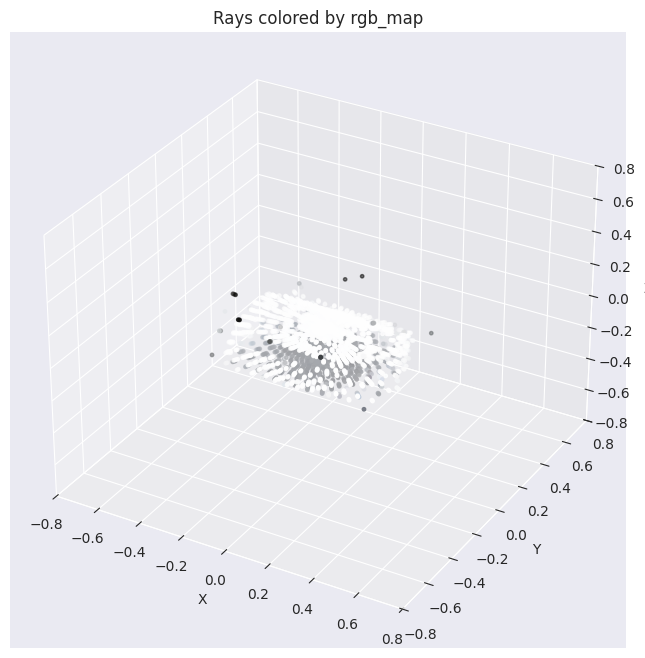

In [75]:
points_with_color_1 = ray_points_1.view(-1, 3)[weight_1 > 0.001]
colours_with_color_1 = (1 - rgb_1.view(-1, 3))[weight_1 > 0.001]
plot_rays_colored(points_with_color_1, colours_with_color_1, special_lim=True)

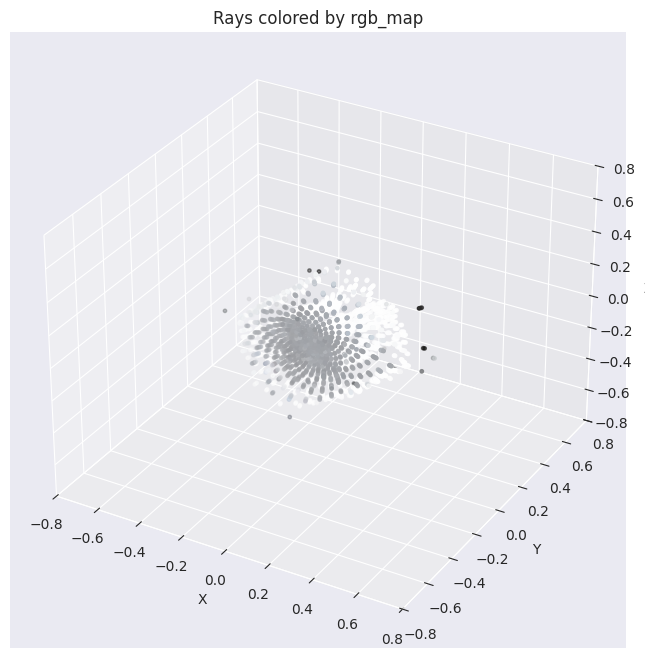

In [72]:
rotated_points_with_color = rotated_ray_points.view(-1, 3)[weight_1 > 0.001]
colours_with_color_1 = (1 - rgb_1.view(-1, 3))[weight_1 > 0.001]
plot_rays_colored(rotated_points_with_color, colours_with_color_1, special_lim=True)

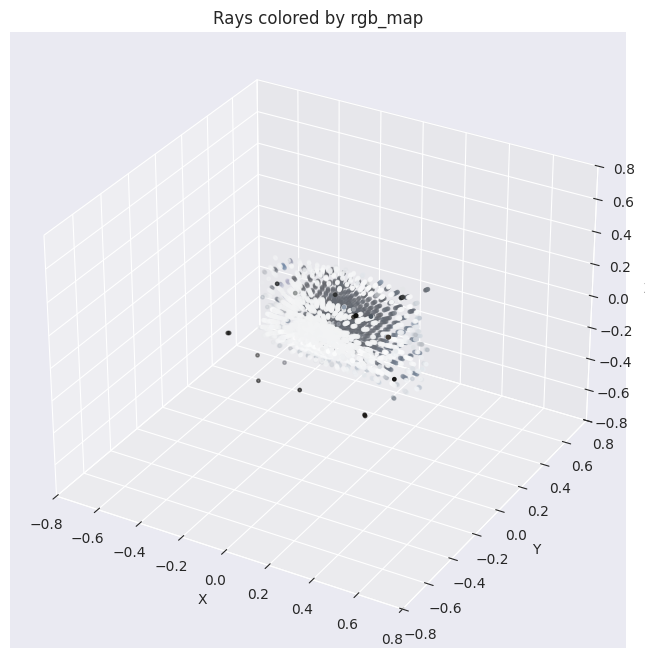

In [73]:
points_with_color_2 = ray_points_2.view(-1, 3)[weight_2 > 0.001]
colours_with_color_2 = (1 - ray_colours_2[:, :, :3].view(-1, 3))[weight_2 > 0.001]
plot_rays_colored(points_with_color_2, colours_with_color_2, special_lim=True)

In [8]:
rotations_1 = torch.from_numpy(np.array([Rotation.random().as_matrix() for x in range(5000)]))
rotations_2 = torch.from_numpy(np.array([Rotation.random().as_matrix() for x in range(5000)]))
rotations_3 = torch.from_numpy(np.array([Rotation.random().as_quat() for x in range(5000)]))

In [9]:
rotations_1_to_2 = torch.matmul(rotations_2, torch.linalg.inv(rotations_1))


In [10]:
og = torch.from_numpy(Rotation.from_matrix(rotations_1_to_2).as_quat()).float()

In [11]:
def get_rot_rmse(predicted_rotation, og_rotation):
    cos_theta = torch.sum(predicted_rotation * og_rotation, dim=-1)
    cos_theta = torch.clamp(cos_theta, -1.0, 1.0)
    rot_rmse = torch.acos(cos_theta)
    rot_rmse = torch.rad2deg(rot_rmse)
    rot_rmse = torch.sqrt(rot_rmse.pow(2).mean())
    return rot_rmse

In [12]:
get_rot_rmse(torch.nn.functional.normalize(torch.tensor([[2,2,2,2]]).float()).repeat(5000, 1), og)

tensor(68.6530)

In [13]:
get_rot_rmse(rotations_3, og)

tensor(95.4081, dtype=torch.float64)

In [14]:
torch.nn.functional.normalize(torch.tensor([[2,2,2,2]]).float()

SyntaxError: incomplete input (618714236.py, line 1)

In [15]:
get_rot_rmse(torch.nn.functional.normalize(torch.tensor([[2,2,2,2]]).float()).repeat(5000, 1), rotations_3))


tensor(94.9302, dtype=torch.float64)

In [22]:
rotations_a = np.array([Rotation.random() for x in range(5000)])
rotations_transform = np.array([Rotation.random() for x in range(5000)])
rotations_b = np.array([trans * a for (a, trans) in zip(rotations_a, rotations_transform)])
normalize
to_matrix_tensor = lambda x : torch.from_numpy(np.array([y.as_matrix() for y in x]))
matrix_tensor_to_quat = lambda x : torch.from_numpy(Rotation.from_matrix(x).as_quat()).float()
rotations_1_to_2 = matrix_tensor_to_quat(torch.matmul(to_matrix_tensor(rotations_b), torch.linalg.inv(to_matrix_tensor(rotations_a))))


[rotations_a, rotations_transform, rotations_b] = [torch.from_numpy(np.array([y.as_quat() for y in x])) for x in [rotations_a, rotations_transform, rotations_b]]


In [18]:
get_rot_rmse(torch.nn.functional.normalize(torch.tensor([[2,2,2,2]]).float()).repeat(5000, 1), rotations_transform)


tensor(95.2256, dtype=torch.float64)